In [ ]:
import torch

for i in range(torch.cuda.device_count()):
    print(i, "->", torch.cuda.get_device_name(i))

0 -> NVIDIA A100-PCIE-40GB
1 -> NVIDIA A100-PCIE-40GB
2 -> NVIDIA A100-PCIE-40GB
3 -> NVIDIA A100-PCIE-40GB
4 -> Tesla V100-PCIE-32GB
5 -> Tesla V100-PCIE-32GB
6 -> Tesla V100-PCIE-32GB


In [ ]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 251 kB 953 kB/s            


In [ ]:
import torch
device = torch.device("cuda:6")   # V100 with most free memory
print(device)
print(torch.cuda.get_device_name(6))

cuda:6
Tesla V100-PCIE-32GB


In [ ]:
import torch

for i in [4, 5, 6]:
    with torch.cuda.device(i):
        free, total = torch.cuda.mem_get_info()
        print(
            f"GPU {i} ({torch.cuda.get_device_name(i)}): "
            f"{free / (1024**3):.2f} GB free / "
            f"{total / (1024**3):.2f} GB total"
        )

GPU 4 (Tesla V100-PCIE-32GB): 3.70 GB free / 31.73 GB total
GPU 5 (Tesla V100-PCIE-32GB): 5.47 GB free / 31.73 GB total
GPU 6 (Tesla V100-PCIE-32GB): 14.71 GB free / 31.73 GB total


In [ ]:
!pip install torch torchvision --upgrade

Defaulting to user installation because normal site-packages is not writeable
  Using cached torch-1.10.2-cp36-cp36m-manylinux1_x86_64.whl (881.9 MB)


In [ ]:
model = ResNet20().to(device)

In [28]:
!pip install pandas

In [ ]:
print(device)
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(torch.cuda.current_device()))

cuda:4
0
NVIDIA A100-PCIE-40GB


In [ ]:
import torch

print("Torch version:", torch.__version__)
print("CUDA version :", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device())
print("GPU name:", torch.cuda.get_device_name(0))

Torch version: 1.10.1+cu102
CUDA version : 10.2
CUDA available: True
Current device: 0
GPU name: NVIDIA A100-PCIE-40GB


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import precision_score, recall_score
import numpy as np

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [21]:
# -----------------------------
# Basic Residual Block
# -----------------------------
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return torch.relu(out)


In [22]:

# -----------------------------
# CIFAR-10 ResNet (Original Paper: 6n+2)
# Exact paper setup uses 16->32->64 channels
# ResNet-20 corresponds to n=3
# -----------------------------
class CIFARResNet(nn.Module):
    def __init__(self, block, n=3, num_classes=10):
        super().__init__()
        self.in_channels = 16

        # First layer: 3x3 conv, 16 filters
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)

        # 3 stages with 2n blocks each
        self.layer1 = self._make_layer(block, 16, n, stride=1)
        self.layer2 = self._make_layer(block, 32, n, stride=2)
        self.layer3 = self._make_layer(block, 64, n, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride):
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

def ResNet20():
    return CIFARResNet(BasicBlock, n=3)

In [23]:
# -----------------------------
# Data Preparation (Exact paper augmentation)
# -----------------------------
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# Use full 50k training set exactly as in the paper
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)

# Use standard 10k test set
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(testset)}")

Training samples: 50000
Test samples: 10000


In [24]:
# -----------------------------
# Print Number of Parameters
# -----------------------------
model = ResNet20().to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"In Millions          : {total_params / 1e6:.3f} M")

Total Parameters     : 272,474
Trainable Parameters : 272,474
In Millions          : 0.272 M


In [25]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


In [26]:
# Store history
history = {
    "Epoch": [],
    "Train Loss": [],
    "Train Accuracy": [],
    "Test Loss": [],
    "Test Accuracy": [],
    "Learning Rate": []
}

In [31]:
# -----------------------------
# Training Loop
# -----------------------------
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[91, 136],
    gamma=0.1
)

num_epochs = 182

def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item()

            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    acc = 100. * correct / total
    avg_loss = total_loss / len(loader)

    return avg_loss, acc


for epoch in range(num_epochs):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total

    #test_loss, test_acc = evaluate(test_loader)

    scheduler.step()
    # Store history
    history["Epoch"].append(epoch + 1)
    history["Train Accuracy"].append(train_acc)
    history["Train Loss"].append(train_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% ")

Epoch [1/182] | Train Loss: 1.6104 | Train Acc: 39.82% 
Epoch [2/182] | Train Loss: 1.1257 | Train Acc: 59.41% 
Epoch [3/182] | Train Loss: 0.9011 | Train Acc: 67.93% 
Epoch [4/182] | Train Loss: 0.7624 | Train Acc: 73.29% 
Epoch [5/182] | Train Loss: 0.6740 | Train Acc: 76.73% 
Epoch [6/182] | Train Loss: 0.6241 | Train Acc: 78.36% 
Epoch [7/182] | Train Loss: 0.5789 | Train Acc: 80.21% 
Epoch [8/182] | Train Loss: 0.5378 | Train Acc: 81.50% 
Epoch [9/182] | Train Loss: 0.5117 | Train Acc: 82.44% 
Epoch [10/182] | Train Loss: 0.4890 | Train Acc: 83.13% 
Epoch [11/182] | Train Loss: 0.4670 | Train Acc: 83.82% 
Epoch [12/182] | Train Loss: 0.4463 | Train Acc: 84.56% 
Epoch [13/182] | Train Loss: 0.4360 | Train Acc: 84.77% 
Epoch [14/182] | Train Loss: 0.4180 | Train Acc: 85.29% 
Epoch [15/182] | Train Loss: 0.4035 | Train Acc: 86.00% 
Epoch [16/182] | Train Loss: 0.3929 | Train Acc: 86.31% 
Epoch [17/182] | Train Loss: 0.3899 | Train Acc: 86.49% 
Epoch [18/182] | Train Loss: 0.3789 | Tr

In [36]:
import pandas as pd

min_len = min(len(v) for v in history.values())

fixed_history = {k: v[:min_len] for k, v in history.items()}

df = pd.DataFrame(fixed_history)

excel_file = "resnet20_cifar10_training_results.xlsx"
df.to_excel(excel_file, index=False)

print(f"Results saved to: {excel_file}")

Results saved to: resnet20_cifar10_training_results.xlsx


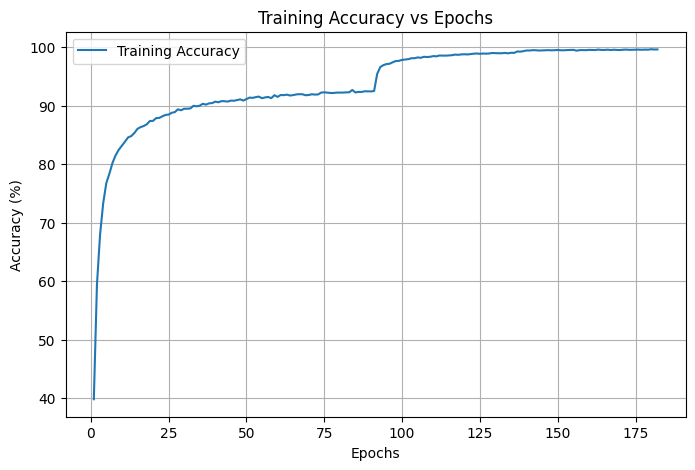

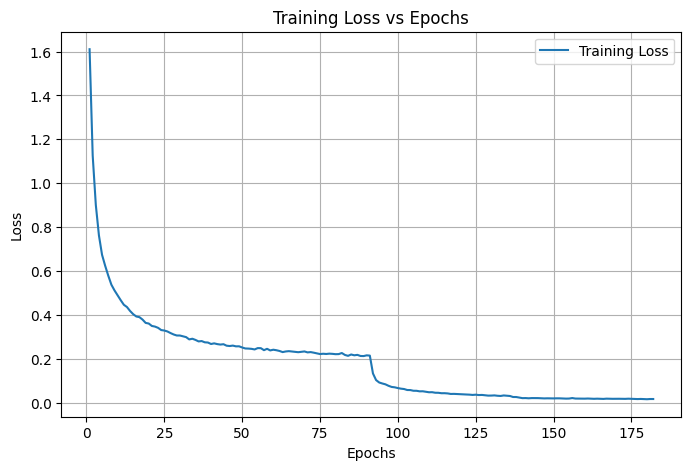

In [32]:
import matplotlib.pyplot as plt

epochs = history["Epoch"]

# Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(epochs, history["Train Accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

# Loss Curve
plt.figure(figsize=(8,5))
plt.plot(epochs, history["Train Loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# -----------------------------
# Final Test Evaluation
# -----------------------------
test_loss, test_acc = evaluate(test_loader)

# Classification error (same as paper)
test_error = 100 - test_acc

# Precision & Recall
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

precision = precision_score(all_targets, all_preds, average='macro')
recall = recall_score(all_targets, all_preds, average='macro')

print("\n===== Final Test Metrics (Paper Style) =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Error: {test_error:.2f}%")
print(f"Test Precision (Macro): {precision:.4f}")
print(f"Test Recall (Macro): {recall:.4f}")


===== Final Test Metrics (Paper Style) =====
Test Loss: 0.3837
Test Accuracy: 91.68%
Test Error: 8.32%
Test Precision (Macro): 0.9169
Test Recall (Macro): 0.9168
